#**Assignement 5: Implement and compare RNN, LSTM, GRU Model for sequence classification and analyze their performance using appropriate evaluation metrics**

In [1]:
#1 Import Libraries and Load IMDb Dataset
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,classification_report)

In [2]:
# Number of words to keep
num_words = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [3]:
#2 Preprocess and Pad Review Sequences

max_sequence_length = 250
x_train = pad_sequences(x_train, maxlen=max_sequence_length)
x_test = pad_sequences(x_test, maxlen=max_sequence_length)

In [17]:
#3 Build the RNN Model
rnn_model = tf.keras.Sequential([tf.keras.layers.Embedding(input_dim=num_words, output_dim=64, input_length=max_sequence_length),
                                 tf.keras.layers.SimpleRNN(64),tf.keras.layers.Dense(1,activation='sigmoid')])

rnn_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
#4 Train RNN
rnn_history = rnn_model.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.2,verbose=1)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 96ms/step - accuracy: 0.6582 - loss: 0.5982 - val_accuracy: 0.8078 - val_loss: 0.4425
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 115ms/step - accuracy: 0.8326 - loss: 0.3912 - val_accuracy: 0.8112 - val_loss: 0.4375
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.8909 - loss: 0.2734 - val_accuracy: 0.7336 - val_loss: 0.5454
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 130ms/step - accuracy: 0.9452 - loss: 0.1525 - val_accuracy: 0.8068 - val_loss: 0.5339
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 98ms/step - accuracy: 0.9772 - loss: 0.0681 - val_accuracy: 0.8058 - val_loss: 0.6151


In [18]:
#5 Build the LSTM Model
lstm_model = tf.keras.Sequential([tf.keras.layers.Embedding(input_dim=num_words,output_dim=64, input_length=max_sequence_length),
                                  tf.keras.layers.LSTM(64),tf.keras.layers.Dense(1,activation='sigmoid')])

lstm_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
#6 Build the GRU Model
gru_model = tf.keras.Sequential([tf.keras.layers.Embedding(input_dim=num_words,output_dim=64, input_length=max_sequence_length),
                                 tf.keras.layers.GRU(64),tf.keras.layers.Dense(1,activation='sigmoid')])

gru_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

gru_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
#7 Train GRU
gru_history = gru_model.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.2,verbose=1)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 252ms/step - accuracy: 0.7599 - loss: 0.4757 - val_accuracy: 0.8108 - val_loss: 0.4283
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 255ms/step - accuracy: 0.8920 - loss: 0.2706 - val_accuracy: 0.8678 - val_loss: 0.3151
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 249ms/step - accuracy: 0.9254 - loss: 0.1962 - val_accuracy: 0.8664 - val_loss: 0.3760
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 78s 249ms/step - accuracy: 0.9475 - loss: 0.1451 - val_accuracy: 0.8400 - val_loss: 0.3801
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 245ms/step - accuracy: 0.9657 - loss: 0.0993 - val_accuracy: 0.8654 - val_loss: 0.4210


In [13]:
#8 Evaluate All Three Models
rnn_pred = (rnn_model.predict(x_test) > 0.5).astype(int).flatten()

lstm_pred = (lstm_model.predict(x_test) > 0.5).astype(int).flatten()

gru_pred = (gru_model.predict(x_test) > 0.5).astype(int).flatten()

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step


In [14]:
#9 Calculate the evaluation metrics
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("\n", name)
    print("-------------------------")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1-Score :", f1)

    return accuracy, precision, recall, f1

rnn_results = evaluate_model("RNN",y_test,rnn_pred)

lstm_results = evaluate_model("LSTM",y_test,lstm_pred)

gru_results = evaluate_model("GRU",y_test,gru_pred)


 RNN
-------------------------
Accuracy : 0.51088
Precision: 0.5123143788482434
Recall   : 0.45264
F1-Score : 0.48063200815494395

 LSTM
-------------------------
Accuracy : 0.49636
Precision: 0.49631966351209256
Recall   : 0.49088
F1-Score : 0.4935848449503278

 GRU
-------------------------
Accuracy : 0.4958
Precision: 0.4959147148081861
Recall   : 0.50984
F1-Score : 0.5027809553863752


In [15]:
#10 Compare Model Performance
results = {'RNN': rnn_results,'LSTM': lstm_results,'GRU': gru_results}

print("\nModel Comparison")
print("============================")

for model_name, metrics in results.items():
    print(model_name, "→ Accuracy:", round(metrics[0], 4),"Precision:", round(metrics[1], 4),"Recall:", round(metrics[2], 4),"F1:", round(metrics[3], 4))


Model Comparison
RNN → Accuracy: 0.5109 Precision: 0.5123 Recall: 0.4526 F1: 0.4806
LSTM → Accuracy: 0.4964 Precision: 0.4963 Recall: 0.4909 F1: 0.4936
GRU → Accuracy: 0.4958 Precision: 0.4959 Recall: 0.5098 F1: 0.5028


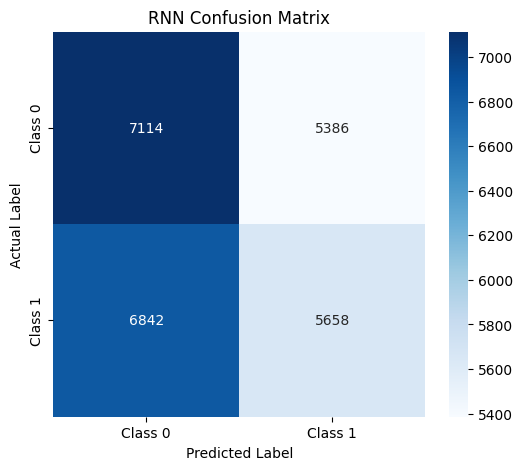

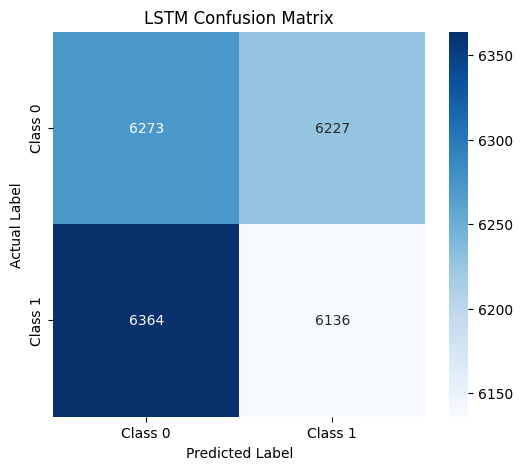

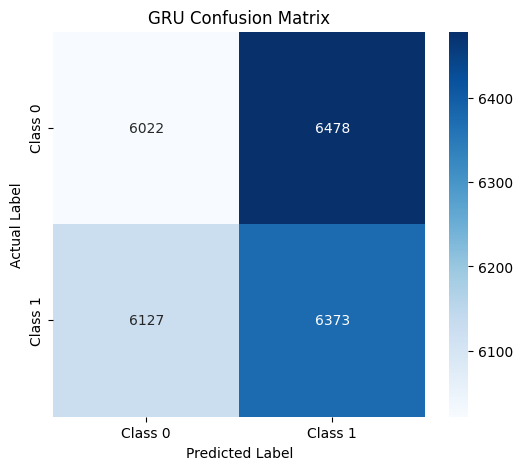

In [23]:
import seaborn as sns
#11 Display Confusion Matrices
models_predictions = {'RNN': rnn_pred,'LSTM': lstm_pred,'GRU': gru_pred}

for name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Class 0', 'Class 1'],yticklabels=['Class 0', 'Class 1'])

    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.show()